In [1]:
# ============================================================
# BÀI 3 - KHAI PHÁ LUẬT KẾT HỢP
# DATASET: DIABETES 130-US HOSPITALS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Đọc dữ liệu Diabetes đã tiền xử lý ở Bài 1
diabetes = pd.read_csv(
    "../data/processed/diabetes_processed.csv"
)

print("=== THÔNG TIN DATASET ===")
print("Kích thước:", diabetes.shape)
print("Số bản ghi:", diabetes.shape[0])
print("Số thuộc tính:", diabetes.shape[1])

diabetes.head()

=== THÔNG TIN DATASET ===
Kích thước: (101766, 46)
Số bản ghi: 101766
Số thuộc tính: 46


,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,8222157,Caucasian,Female,[0-10),6,25,1,1,Unknown,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,NO
1,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,Unknown,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,Unknown,...,No,No,No,No,No,No,No,No,Yes,NO
3,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,Unknown,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,Unknown,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
# ============================================================
# BƯỚC 2 - CHỌN THUỘC TÍNH CHO LUẬT KẾT HỢP
# ============================================================

association_cols = [
    "race",
    "gender",
    "age",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "medical_specialty",
    "diag_1",
    "readmitted"
]

# Kiểm tra các cột có tồn tại
association_cols = [
    col for col in association_cols
    if col in diabetes.columns
]

association_data = diabetes[association_cols].copy()

print("=== DỮ LIỆU DÙNG CHO LUẬT KẾT HỢP ===")
print("Kích thước:", association_data.shape)
print("Số thuộc tính:", len(association_cols))

print("\n=== CÁC THUỘC TÍNH ĐƯỢC CHỌN ===")
for col in association_cols:
    print(
        f"{col}: {association_data[col].nunique()} giá trị khác nhau"
    )

print("\n=== 5 BẢN GHI ĐẦU ===")
display(association_data.head())

=== DỮ LIỆU DÙNG CHO LUẬT KẾT HỢP ===
Kích thước: (101766, 9)
Số thuộc tính: 9

=== CÁC THUỘC TÍNH ĐƯỢC CHỌN ===
race: 6 giá trị khác nhau
gender: 3 giá trị khác nhau
age: 10 giá trị khác nhau
admission_type_id: 8 giá trị khác nhau
discharge_disposition_id: 26 giá trị khác nhau
admission_source_id: 17 giá trị khác nhau
medical_specialty: 73 giá trị khác nhau
diag_1: 717 giá trị khác nhau
readmitted: 3 giá trị khác nhau

=== 5 BẢN GHI ĐẦU ===


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,medical_specialty,diag_1,readmitted
0,Caucasian,Female,[0-10),6,25,1,Pediatrics-Endocrinology,250.83,NO
1,Caucasian,Female,[10-20),1,1,7,Unknown,276,>30
2,AfricanAmerican,Female,[20-30),1,1,7,Unknown,648,NO
3,Caucasian,Male,[30-40),1,1,7,Unknown,8,NO
4,Caucasian,Male,[40-50),1,1,7,Unknown,197,NO


In [3]:
# ============================================================
# BƯỚC 3 - TẠO TRANSACTION CHO LUẬT KẾT HỢP
# ============================================================

rule_cols = [
    "race",
    "gender",
    "age",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "readmitted"
]

rule_data = diabetes[rule_cols].copy()

# Chuyển tất cả về chuỗi
for col in rule_cols:
    rule_data[col] = rule_data[col].astype(str)

# Mỗi dòng bệnh án = một transaction
transactions = rule_data.apply(
    lambda row: [
        f"{col}={row[col]}"
        for col in rule_cols
    ],
    axis=1
).tolist()

print("=== TRANSACTIONS ===")
print("Tổng số transaction:", len(transactions))
print("Số item trong mỗi transaction:", len(transactions[0]))

print("\n=== 5 TRANSACTION ĐẦU TIÊN ===")
for i, transaction in enumerate(transactions[:5], 1):
    print(f"{i}. {transaction}")

# Kiểm tra tổng số item khác nhau
unique_items = set(
    item
    for transaction in transactions
    for item in transaction
)

print("\nTổng số item khác nhau:", len(unique_items))

=== TRANSACTIONS ===
Tổng số transaction: 101766
Số item trong mỗi transaction: 7

=== 5 TRANSACTION ĐẦU TIÊN ===
1. ['race=Caucasian', 'gender=Female', 'age=[0-10)', 'admission_type_id=6', 'discharge_disposition_id=25', 'admission_source_id=1', 'readmitted=NO']
2. ['race=Caucasian', 'gender=Female', 'age=[10-20)', 'admission_type_id=1', 'discharge_disposition_id=1', 'admission_source_id=7', 'readmitted=>30']
3. ['race=AfricanAmerican', 'gender=Female', 'age=[20-30)', 'admission_type_id=1', 'discharge_disposition_id=1', 'admission_source_id=7', 'readmitted=NO']
4. ['race=Caucasian', 'gender=Male', 'age=[30-40)', 'admission_type_id=1', 'discharge_disposition_id=1', 'admission_source_id=7', 'readmitted=NO']
5. ['race=Caucasian', 'gender=Male', 'age=[40-50)', 'admission_type_id=1', 'discharge_disposition_id=1', 'admission_source_id=7', 'readmitted=NO']

Tổng số item khác nhau: 73


In [4]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

print("Đã tải mlxtend thành công!")

Đã tải mlxtend thành công!


In [5]:
# ============================================================
# BƯỚC 5 - MÃ HÓA TRANSACTION VÀ CHẠY APRIORI
# ============================================================

# 1. Mã hóa transaction thành dạng True/False
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

basket_df = pd.DataFrame(
    te_array,
    columns=te.columns_
)

print("=== DỮ LIỆU SAU KHI MÃ HÓA ===")
print("Kích thước:", basket_df.shape)
print("Số transaction:", basket_df.shape[0])
print("Số item:", basket_df.shape[1])

print("\n5 transaction đầu:")
display(basket_df.head())

# 2. Chạy Apriori
# Itemset phải xuất hiện trong ít nhất 5% số transaction
frequent_itemsets = apriori(
    basket_df,
    min_support=0.05,
    use_colnames=True
)

# Thêm số lượng item trong mỗi tập
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)

# Sắp xếp theo support giảm dần
frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
).reset_index(drop=True)

print("\n=== FREQUENT ITEMSETS ===")
print("Số frequent itemsets tìm được:", len(frequent_itemsets))

display(frequent_itemsets.head(20))

print("\n=== SỐ ITEMSET THEO ĐỘ DÀI ===")
print(
    frequent_itemsets["length"]
    .value_counts()
    .sort_index()
)

=== DỮ LIỆU SAU KHI MÃ HÓA ===
Kích thước: (101766, 73)
Số transaction: 101766
Số item: 73

5 transaction đầu:


,admission_source_id=1,admission_source_id=10,admission_source_id=11,admission_source_id=13,admission_source_id=14,admission_source_id=17,admission_source_id=2,admission_source_id=20,admission_source_id=22,admission_source_id=25,...,gender=Unknown/Invalid,race=AfricanAmerican,race=Asian,race=Caucasian,race=Hispanic,race=Other,race=Unknown,readmitted=<30,readmitted=>30,readmitted=NO
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True



=== FREQUENT ITEMSETS ===
Số frequent itemsets tìm được: 415


,support,itemsets,length
0,0.747784,frozenset({race=Caucasian}),1
1,0.591887,frozenset({discharge_disposition_id=1}),1
2,0.564963,frozenset({admission_source_id=7}),1
3,0.539119,frozenset({readmitted=NO}),1
4,0.537586,frozenset({gender=Female}),1
5,0.530531,frozenset({admission_type_id=1}),1
6,0.476731,"frozenset({admission_source_id=7, admission_ty...",2
7,0.462384,frozenset({gender=Male}),1
8,0.428964,"frozenset({discharge_disposition_id=1, race=Ca...",2
9,0.411699,"frozenset({admission_source_id=7, race=Caucasi...",2



=== SỐ ITEMSET THEO ĐỘ DÀI ===
length
1     22
2    114
3    175
4     87
5     16
6      1
Name: count, dtype: int64


In [6]:
# ============================================================
# BƯỚC 6 - SINH LUẬT KẾT HỢP
# ============================================================

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.6
)

# Chỉ giữ các cột quan trọng
rules_result = rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].copy()

# Sắp xếp ưu tiên Lift, sau đó Confidence
rules_result = rules_result.sort_values(
    by=["lift", "confidence"],
    ascending=False
).reset_index(drop=True)

print("=== LUẬT KẾT HỢP ===")
print("Tổng số luật tìm được:", len(rules_result))

print("\n=== 20 LUẬT CÓ LIFT CAO NHẤT ===")
display(rules_result.head(20))

print("\n=== THỐNG KÊ ===")
print("Support:")
print(rules_result["support"].describe())

print("\nConfidence:")
print(rules_result["confidence"].describe())

print("\nLift:")
print(rules_result["lift"].describe())

=== LUẬT KẾT HỢP ===
Tổng số luật tìm được: 437

=== 20 LUẬT CÓ LIFT CAO NHẤT ===


,antecedents,consequents,support,confidence,lift
0,"frozenset({admission_type_id=3, gender=Male})","frozenset({race=Caucasian, admission_source_id...",0.063597,0.716881,3.167648
1,"frozenset({admission_type_id=3, discharge_disp...",frozenset({admission_source_id=1}),0.051766,0.892125,3.070794
2,"frozenset({admission_type_id=3, discharge_disp...",frozenset({admission_source_id=1}),0.079948,0.892105,3.070725
3,"frozenset({admission_type_id=3, discharge_disp...","frozenset({race=Caucasian, admission_source_id...",0.079948,0.693547,3.064544
4,"frozenset({admission_type_id=3, discharge_disp...",frozenset({admission_source_id=1}),0.102461,0.888842,3.059491
5,"frozenset({admission_type_id=3, discharge_disp...",frozenset({admission_source_id=1}),0.062428,0.887167,3.053726
6,"frozenset({admission_type_id=3, discharge_disp...",frozenset({admission_source_id=1}),0.050685,0.885494,3.047967
7,frozenset({admission_type_id=3}),"frozenset({race=Caucasian, admission_source_id...",0.126575,0.682654,3.016412
8,"frozenset({admission_type_id=3, race=Caucasian...",frozenset({admission_source_id=1}),0.063597,0.868142,2.988241
9,"frozenset({admission_type_id=3, readmitted=NO})","frozenset({race=Caucasian, admission_source_id...",0.073826,0.673087,2.974139



=== THỐNG KÊ ===
Support:
count    437.000000
mean       0.104870
std        0.069963
min        0.050390
25%        0.061858
50%        0.079634
75%        0.116542
max        0.476731
Name: support, dtype: float64

Confidence:
count    437.000000
mean       0.745429
std        0.101880
min        0.600102
25%        0.647676
50%        0.736750
75%        0.834717
max        0.938083
Name: confidence, dtype: float64

Lift:
count    437.000000
mean       1.307772
std        0.445043
min        0.846556
25%        1.024980
50%        1.107614
75%        1.582655
max        3.167648
Name: lift, dtype: float64


In [7]:
# ============================================================
# BƯỚC 7 - LỌC VÀ TRÌNH BÀY CÁC LUẬT KẾT HỢP
# ============================================================

# Chuyển frozenset thành chuỗi dễ đọc
rules_display = rules_result.copy()

rules_display["antecedents"] = rules_display["antecedents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

rules_display["consequents"] = rules_display["consequents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

# Làm tròn các chỉ số
rules_display["support"] = rules_display["support"].round(4)
rules_display["confidence"] = rules_display["confidence"].round(4)
rules_display["lift"] = rules_display["lift"].round(4)

print("=== 20 LUẬT CÓ LIFT CAO NHẤT ===")
display(rules_display.head(20))

# ------------------------------------------------------------
# Lọc luật có vế phải liên quan đến readmitted
# ------------------------------------------------------------

readmission_rules = rules_display[
    rules_display["consequents"].str.contains(
        "readmitted=", regex=False
    )
].copy()

readmission_rules = readmission_rules.sort_values(
    by=["lift", "confidence"],
    ascending=False
).reset_index(drop=True)

print("\n=== LUẬT LIÊN QUAN ĐẾN TÁI NHẬP VIỆN ===")
print("Số luật:", len(readmission_rules))

display(readmission_rules.head(20))

=== 20 LUẬT CÓ LIFT CAO NHẤT ===


,antecedents,consequents,support,confidence,lift
0,"admission_type_id=3, gender=Male","admission_source_id=1, race=Caucasian",0.0636,0.7169,3.1676
1,"admission_type_id=3, discharge_disposition_id=...",admission_source_id=1,0.0518,0.8921,3.0708
2,"admission_type_id=3, discharge_disposition_id=...",admission_source_id=1,0.0799,0.8921,3.0707
3,"admission_type_id=3, discharge_disposition_id=1","admission_source_id=1, race=Caucasian",0.0799,0.6935,3.0645
4,"admission_type_id=3, discharge_disposition_id=1",admission_source_id=1,0.1025,0.8888,3.0595
5,"admission_type_id=3, discharge_disposition_id=...",admission_source_id=1,0.0624,0.8872,3.0537
6,"admission_type_id=3, discharge_disposition_id=...",admission_source_id=1,0.0507,0.8855,3.0480
7,admission_type_id=3,"admission_source_id=1, race=Caucasian",0.1266,0.6827,3.0164
8,"admission_type_id=3, gender=Male, race=Caucasian",admission_source_id=1,0.0636,0.8681,2.9882
9,"admission_type_id=3, readmitted=NO","admission_source_id=1, race=Caucasian",0.0738,0.6731,2.9741



=== LUẬT LIÊN QUAN ĐẾN TÁI NHẬP VIỆN ===
Số luật: 2


,antecedents,consequents,support,confidence,lift
0,"admission_type_id=3, discharge_disposition_id=1",readmitted=NO,0.0704,0.6104,1.1323
1,"admission_source_id=1, admission_type_id=3, di...",readmitted=NO,0.0624,0.6093,1.1301


In [8]:
# ============================================================
# BƯỚC 8 - KHAI THÁC SÂU LUẬT LIÊN QUAN ĐẾN READMITTED
# ============================================================

# Sinh lại luật với confidence >= 30%
rules_deep = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.30
)

# Chỉ lấy luật có vế phải chứa readmitted
readmission_deep = rules_deep[
    rules_deep["consequents"].apply(
        lambda x: any(
            str(item).startswith("readmitted=")
            for item in x
        )
    )
].copy()

# Chỉ giữ luật có lift > 1
readmission_deep = readmission_deep[
    readmission_deep["lift"] > 1
].copy()

# Chuyển sang dạng dễ đọc
readmission_deep["antecedents"] = readmission_deep["antecedents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

readmission_deep["consequents"] = readmission_deep["consequents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

# Làm tròn
for col in ["support", "confidence", "lift"]:
    readmission_deep[col] = readmission_deep[col].round(4)

# Sắp xếp theo lift
readmission_deep = readmission_deep.sort_values(
    ["lift", "confidence"],
    ascending=False
).reset_index(drop=True)

print("=== LUẬT READMITTED VỚI CONFIDENCE >= 30% VÀ LIFT > 1 ===")
print("Tổng số luật:", len(readmission_deep))

display(
    readmission_deep[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].head(30)
)

print("\n=== SỐ LUẬT THEO KẾT QUẢ READMITTED ===")

for target in ["readmitted=NO", "readmitted=>30", "readmitted=<30"]:
    count = readmission_deep[
        readmission_deep["consequents"] == target
    ].shape[0]

    print(f"{target}: {count} luật")

=== LUẬT READMITTED VỚI CONFIDENCE >= 30% VÀ LIFT > 1 ===
Tổng số luật: 191


,antecedents,consequents,support,confidence,lift
0,"admission_type_id=3, discharge_disposition_id=1","admission_source_id=1, readmitted=NO",0.0624,0.5416,3.2815
1,admission_type_id=3,"admission_source_id=1, race=Caucasian, readmit...",0.0738,0.3982,3.1401
2,admission_type_id=3,"admission_source_id=1, discharge_disposition_i...",0.0624,0.3367,3.0983
3,admission_type_id=3,"admission_source_id=1, readmitted=NO",0.0944,0.5093,3.0860
4,"admission_source_id=1, discharge_disposition_id=1","admission_type_id=3, readmitted=NO",0.0624,0.3377,3.0790
5,"admission_type_id=3, race=Caucasian","admission_source_id=1, readmitted=NO",0.0738,0.5010,3.0355
6,"admission_source_id=1, race=Caucasian","admission_type_id=3, readmitted=NO",0.0738,0.3262,2.9741
7,admission_source_id=1,"admission_type_id=3, readmitted=NO",0.0944,0.3250,2.9635
8,"admission_source_id=7, discharge_disposition_i...","admission_type_id=1, readmitted=>30",0.0569,0.3319,1.7494
9,"admission_source_id=7, discharge_disposition_i...","admission_type_id=1, readmitted=>30",0.0771,0.3275,1.7262



=== SỐ LUẬT THEO KẾT QUẢ READMITTED ===
readmitted=NO: 37 luật
readmitted=>30: 50 luật
readmitted=<30: 0 luật


In [9]:
# ============================================================
# BƯỚC 9 - LỌC LUẬT CÓ VẾ PHẢI CHỈ LÀ READMITTED
# ============================================================

# Dùng rules_deep gốc vì antecedents/consequents vẫn là frozenset
target_rules = rules_deep[
    (rules_deep["consequents"].apply(len) == 1) &
    (rules_deep["consequents"].apply(
        lambda x: next(iter(x)).startswith("readmitted=")
    )) &
    (rules_deep["lift"] > 1)
].copy()

# Chuyển sang chuỗi để hiển thị
target_rules["antecedents_text"] = target_rules["antecedents"].apply(
    lambda x: ", ".join(sorted(x))
)

target_rules["consequents_text"] = target_rules["consequents"].apply(
    lambda x: ", ".join(sorted(x))
)

# Sắp xếp theo Lift
target_rules = target_rules.sort_values(
    ["lift", "confidence"],
    ascending=False
).reset_index(drop=True)

print("=== LUẬT CÓ VẾ PHẢI CHỈ LÀ READMITTED ===")
print("Tổng số luật:", len(target_rules))

# Thống kê từng loại kết quả
print("\n=== SỐ LUẬT THEO KẾT QUẢ ===")
for target in ["readmitted=NO", "readmitted=>30", "readmitted=<30"]:
    count = (
        target_rules["consequents_text"] == target
    ).sum()

    print(f"{target}: {count} luật")

print("\n=== 20 LUẬT CÓ LIFT CAO NHẤT ===")

display(
    target_rules[
        [
            "antecedents_text",
            "consequents_text",
            "support",
            "confidence",
            "lift"
        ]
    ].head(20).round({
        "support": 4,
        "confidence": 4,
        "lift": 4
    })
)

=== LUẬT CÓ VẾ PHẢI CHỈ LÀ READMITTED ===
Tổng số luật: 87

=== SỐ LUẬT THEO KẾT QUẢ ===
readmitted=NO: 37 luật
readmitted=>30: 50 luật
readmitted=<30: 0 luật

=== 20 LUẬT CÓ LIFT CAO NHẤT ===


,antecedents_text,consequents_text,support,confidence,lift
0,discharge_disposition_id=6,readmitted=>30,0.0527,0.4156,1.1899
1,"admission_source_id=7, discharge_disposition_i...",readmitted=>30,0.0952,0.4043,1.1575
2,"admission_source_id=7, discharge_disposition_i...",readmitted=>30,0.0687,0.4005,1.1467
3,"admission_type_id=3, discharge_disposition_id=1",readmitted=NO,0.0704,0.6104,1.1323
4,"admission_source_id=7, gender=Female, race=Cau...",readmitted=>30,0.0859,0.3953,1.1316
5,"admission_source_id=1, admission_type_id=3, di...",readmitted=NO,0.0624,0.6093,1.1301
6,"admission_source_id=7, admission_type_id=1, di...",readmitted=>30,0.0771,0.3938,1.1274
7,"admission_source_id=7, discharge_disposition_id=1",readmitted=>30,0.1307,0.3913,1.1204
8,"admission_source_id=7, admission_type_id=1, di...",readmitted=>30,0.0569,0.3908,1.1187
9,"admission_source_id=7, age=[70-80)",readmitted=>30,0.0545,0.3902,1.1171


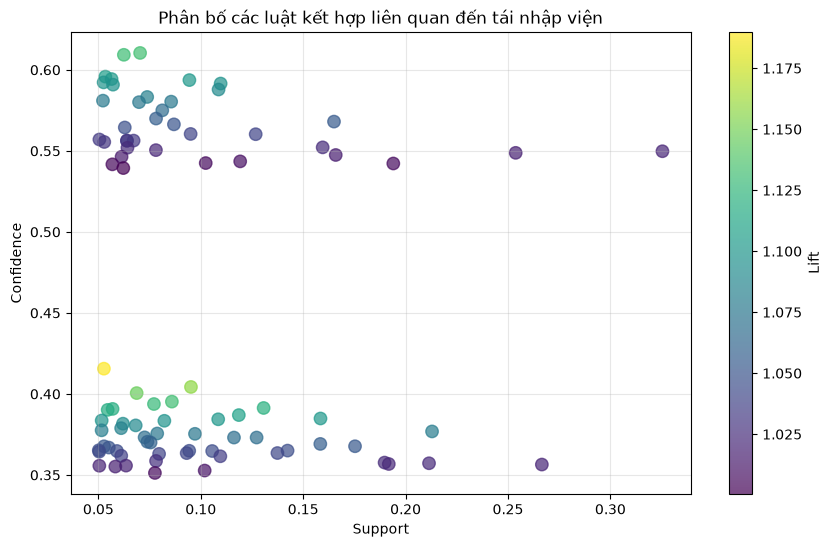

In [10]:
# ============================================================
# BƯỚC 10 - TRỰC QUAN HÓA LUẬT KẾT HỢP
# ============================================================

import matplotlib.pyplot as plt

# Biểu đồ scatter Support - Confidence
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    target_rules["support"],
    target_rules["confidence"],
    c=target_rules["lift"],
    s=80,
    alpha=0.7
)

plt.colorbar(scatter, label="Lift")

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Phân bố các luật kết hợp liên quan đến tái nhập viện")
plt.grid(alpha=0.3)

plt.show()

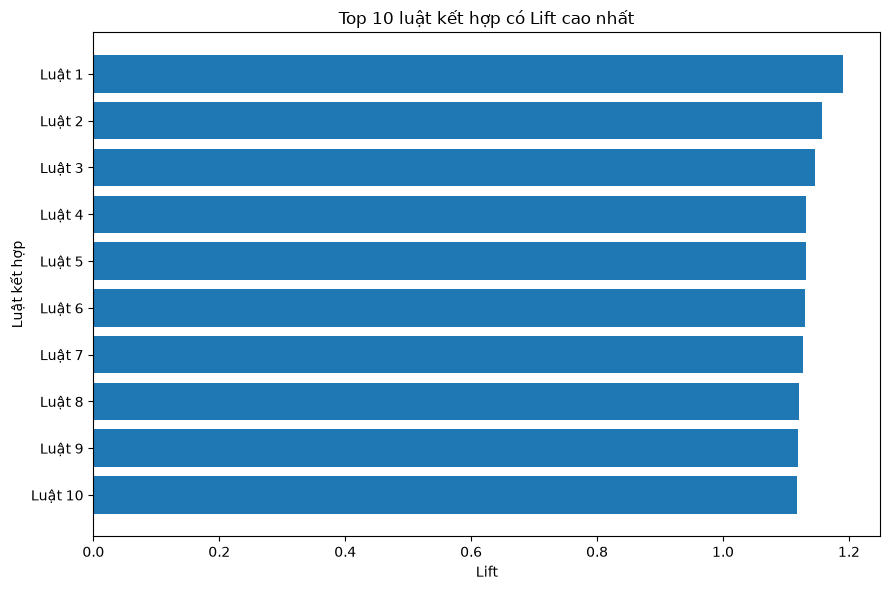

=== CHI TIẾT TOP 10 LUẬT ===

Luật 1: discharge_disposition_id=6 → readmitted=>30
   Support = 0.0527 | Confidence = 0.4156 | Lift = 1.1899

Luật 2: admission_source_id=7, discharge_disposition_id=1, race=Caucasian → readmitted=>30
   Support = 0.0952 | Confidence = 0.4043 | Lift = 1.1575

Luật 3: admission_source_id=7, discharge_disposition_id=1, gender=Female → readmitted=>30
   Support = 0.0687 | Confidence = 0.4005 | Lift = 1.1467

Luật 4: admission_type_id=3, discharge_disposition_id=1 → readmitted=NO
   Support = 0.0704 | Confidence = 0.6104 | Lift = 1.1323

Luật 5: admission_source_id=7, gender=Female, race=Caucasian → readmitted=>30
   Support = 0.0859 | Confidence = 0.3953 | Lift = 1.1316

Luật 6: admission_source_id=1, admission_type_id=3, discharge_disposition_id=1 → readmitted=NO
   Support = 0.0624 | Confidence = 0.6093 | Lift = 1.1301

Luật 7: admission_source_id=7, admission_type_id=1, discharge_disposition_id=1, race=Caucasian → readmitted=>30
   Support = 0.0771 | Conf

In [13]:
# ============================================================
# TOP 10 LUẬT CÓ LIFT CAO NHẤT - PHIÊN BẢN DỄ ĐỌC
# ============================================================

top10 = target_rules.head(10).copy()

# Đặt tên ngắn cho từng luật
top10["Tên luật"] = [
    f"Luật {i}" for i in range(1, len(top10) + 1)
]

# Vẽ biểu đồ
plt.figure(figsize=(9, 6))

plt.barh(
    top10["Tên luật"],
    top10["lift"]
)

plt.xlabel("Lift")
plt.ylabel("Luật kết hợp")
plt.title("Top 10 luật kết hợp có Lift cao nhất")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================================
# HIỂN THỊ NỘI DUNG CÁC LUẬT
# ============================================================

print("=== CHI TIẾT TOP 10 LUẬT ===\n")

for i, (_, row) in enumerate(top10.iterrows(), 1):
    print(
        f"Luật {i}: "
        f"{row['antecedents_text']} "
        f"→ {row['consequents_text']}"
    )
    print(
        f"   Support = {row['support']:.4f} | "
        f"Confidence = {row['confidence']:.4f} | "
        f"Lift = {row['lift']:.4f}"
    )
    print()

In [12]:
# ============================================================
# BƯỚC 11 - TỔNG HỢP KẾT QUẢ
# ============================================================

# Chọn 10 luật có Lift cao nhất
final_rules = target_rules[
    [
        "antecedents_text",
        "consequents_text",
        "support",
        "confidence",
        "lift"
    ]
].head(10).copy()

final_rules.columns = [
    "Vế trái",
    "Vế phải",
    "Support",
    "Confidence",
    "Lift"
]

final_rules["Support"] = final_rules["Support"].round(4)
final_rules["Confidence"] = final_rules["Confidence"].round(4)
final_rules["Lift"] = final_rules["Lift"].round(4)

print("=== 10 LUẬT KẾT HỢP TIÊU BIỂU ===")
display(final_rules)

print("\n=== TỔNG KẾT ===")
print("Số transaction:", len(transactions))
print("Số item khác nhau:", len(unique_items))
print("Số frequent itemsets:", len(frequent_itemsets))
print("Số luật có vế phải chỉ là readmitted:", len(target_rules))

print("\nPhân bố luật:")
print(
    target_rules["consequents_text"]
    .value_counts()
)

=== 10 LUẬT KẾT HỢP TIÊU BIỂU ===


,Vế trái,Vế phải,Support,Confidence,Lift
0,discharge_disposition_id=6,readmitted=>30,0.0527,0.4156,1.1899
1,"admission_source_id=7, discharge_disposition_i...",readmitted=>30,0.0952,0.4043,1.1575
2,"admission_source_id=7, discharge_disposition_i...",readmitted=>30,0.0687,0.4005,1.1467
3,"admission_type_id=3, discharge_disposition_id=1",readmitted=NO,0.0704,0.6104,1.1323
4,"admission_source_id=7, gender=Female, race=Cau...",readmitted=>30,0.0859,0.3953,1.1316
5,"admission_source_id=1, admission_type_id=3, di...",readmitted=NO,0.0624,0.6093,1.1301
6,"admission_source_id=7, admission_type_id=1, di...",readmitted=>30,0.0771,0.3938,1.1274
7,"admission_source_id=7, discharge_disposition_id=1",readmitted=>30,0.1307,0.3913,1.1204
8,"admission_source_id=7, admission_type_id=1, di...",readmitted=>30,0.0569,0.3908,1.1187
9,"admission_source_id=7, age=[70-80)",readmitted=>30,0.0545,0.3902,1.1171



=== TỔNG KẾT ===
Số transaction: 101766
Số item khác nhau: 73
Số frequent itemsets: 415
Số luật có vế phải chỉ là readmitted: 87

Phân bố luật:
consequents_text
readmitted=>30    50
readmitted=NO     37
Name: count, dtype: int64


In [16]:
# Kiểm tra các DataFrame hiện có trong notebook
for name, obj in globals().items():
    if isinstance(obj, pd.DataFrame):
        if obj.shape == (101766, 73):
            print(name, obj.shape)

basket_df (101766, 73)


In [19]:
# ============================================================
# BƯỚC 12 - SO SÁNH 2 CẤU HÌNH APRIORI
# ============================================================

from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd
import time


# ------------------------------------------------------------
# Hàm chạy Apriori với một cấu hình
# ------------------------------------------------------------
def run_apriori_config(
    data,
    min_support,
    min_confidence,
    name
):
    print(f"\n=== {name} ===")
    print(f"Min Support    : {min_support}")
    print(f"Min Confidence : {min_confidence}")

    start_time = time.time()

    # Tìm frequent itemsets
    itemsets = apriori(
        data,
        min_support=min_support,
        use_colnames=True
    )

    # Sinh luật kết hợp
    rules = association_rules(
        itemsets,
        metric="confidence",
        min_threshold=min_confidence
    )

    end_time = time.time()
    elapsed_time = end_time - start_time

    print("Số frequent itemsets:", len(itemsets))
    print("Số luật kết hợp     :", len(rules))
    print(f"Thời gian chạy      : {elapsed_time:.2f} giây")

    # Thống kê Lift
    if len(rules) > 0:
        print(f"Lift trung bình      : {rules['lift'].mean():.4f}")
        print(f"Lift lớn nhất        : {rules['lift'].max():.4f}")
    else:
        print("Không tìm thấy luật kết hợp.")

    result = {
        "Cấu hình": name,
        "Min Support": min_support,
        "Min Confidence": min_confidence,
        "Frequent Itemsets": len(itemsets),
        "Số luật": len(rules),
        "Lift trung bình": (
            round(rules["lift"].mean(), 4)
            if len(rules) > 0 else 0
        ),
        "Lift lớn nhất": (
            round(rules["lift"].max(), 4)
            if len(rules) > 0 else 0
        ),
        "Thời gian (giây)": round(elapsed_time, 2)
    }

    return result, rules


# ============================================================
# CẤU HÌNH 1
# Support >= 5%
# Confidence >= 30%
# ============================================================

result_1, rules_config_1 = run_apriori_config(
    basket_df,
    min_support=0.05,
    min_confidence=0.30,
    name="Cấu hình 1"
)


# ============================================================
# CẤU HÌNH 2
# Support >= 7%
# Confidence >= 40%
# ============================================================

result_2, rules_config_2 = run_apriori_config(
    basket_df,
    min_support=0.07,
    min_confidence=0.40,
    name="Cấu hình 2"
)


# ============================================================
# TẠO BẢNG SO SÁNH
# ============================================================

comparison = pd.DataFrame([
    result_1,
    result_2
])

print("\n=== SO SÁNH 2 CẤU HÌNH APRIORI ===")

display(comparison)


# ============================================================
# CHÊNH LỆCH GIỮA HAI CẤU HÌNH
# ============================================================

print("\n=== NHẬN XÉT SƠ BỘ ===")

print(
    "Chênh lệch Frequent Itemsets:",
    len(rules_config_1) - len(rules_config_2)
)

print(
    "Số luật cấu hình 1:",
    len(rules_config_1)
)

print(
    "Số luật cấu hình 2:",
    len(rules_config_2)
)



=== Cấu hình 1 ===
Min Support    : 0.05
Min Confidence : 0.3
Số frequent itemsets: 415
Số luật kết hợp     : 1594
Thời gian chạy      : 0.69 giây
Lift trung bình      : 1.2171
Lift lớn nhất        : 3.2815

=== Cấu hình 2 ===
Min Support    : 0.07
Min Confidence : 0.4
Số frequent itemsets: 265
Số luật kết hợp     : 753
Thời gian chạy      : 0.35 giây
Lift trung bình      : 1.2300
Lift lớn nhất        : 3.1401

=== SO SÁNH 2 CẤU HÌNH APRIORI ===


,Cấu hình,Min Support,Min Confidence,Frequent Itemsets,Số luật,Lift trung bình,Lift lớn nhất,Thời gian (giây)
0,Cấu hình 1,0.05,0.3,415,1594,1.2171,3.2815,0.69
1,Cấu hình 2,0.07,0.4,265,753,1.2300,3.1401,0.35



=== NHẬN XÉT SƠ BỘ ===
Chênh lệch Frequent Itemsets: 841
Số luật cấu hình 1: 1594
Số luật cấu hình 2: 753


### Nhận xét so sánh hai cấu hình Apriori

Hai cấu hình Apriori được thử nghiệm nhằm đánh giá ảnh hưởng của ngưỡng Support và Confidence đến kết quả khai phá luật kết hợp.

- **Cấu hình 1:** Min Support = 0.05, Min Confidence = 0.30.
  Kết quả thu được 415 frequent itemsets và 1594 luật kết hợp. Lift trung bình đạt 1.2171 và Lift lớn nhất đạt 3.2815.

- **Cấu hình 2:** Min Support = 0.07, Min Confidence = 0.40.
  Kết quả thu được 265 frequent itemsets và 753 luật kết hợp. Lift trung bình đạt 1.2300 và Lift lớn nhất đạt 3.1401.

Khi tăng ngưỡng Support và Confidence, số frequent itemsets giảm từ 415 xuống 265 và số luật giảm từ 1594 xuống 753. Điều này cho thấy việc sử dụng ngưỡng cao hơn giúp loại bỏ nhiều mẫu và luật ít phổ biến, đồng thời làm giảm thời gian xử lý từ 0.69 giây xuống 0.35 giây.

Lift trung bình của cấu hình 2 cao hơn nhẹ so với cấu hình 1 (1.2300 so với 1.2171), trong khi cấu hình 1 tìm được luật có Lift lớn nhất cao hơn (3.2815 so với 3.1401).

Trong bài này, cấu hình 1 được sử dụng để phân tích chi tiết vì ngưỡng thấp hơn cho phép khai thác được nhiều luật tiềm năng hơn. Sau đó, các luật được tiếp tục lọc theo Confidence, Lift và biến mục tiêu `readmitted` để lựa chọn các luật có ý nghĩa cho phân tích.